In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart_disease_uci.csv')

# Question 1: Inspection & Missing Values
display(df.head())
df.info()
display(df.describe())

print("\n--- Missing Values per Column ---")
print(df.isnull().sum())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000



--- Missing Values per Column ---
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# معالجة القيم المفقودة في متغيرات الانحدار الخطي
df_reg = df[['age', 'thalch']].dropna()

X = df_reg[['age']]
y = df_reg['thalch']

# تقسيم البيانات 70:30 وتدريب النموذج (Q2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

y_pred = model_reg.predict(X_test)

# حساب MSE و R2 score (Q2)
print("--- Linear Regression Results ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# استخراج المعاملات وطباعة المعادلة (Q3)
theta_1 = model_reg.coef_[0]
theta_0 = model_reg.intercept_
print(f"\nFinal Line Equation: y_hat = ({theta_1:.4f}) * age + ({theta_0:.4f})")

--- Linear Regression Results ---
Mean Squared Error (MSE): 582.4967
R2 Score: 0.1366

Final Line Equation: y_hat = (-1.0128) * age + (191.1407)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. دالة Sigmoid اليدوية (Q4)
def my_sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. تجهيز الهدف Binary (0 أو 1) والمعالم (Q4)
df['target_binary'] = (df['num'] > 0).astype(int)

df_cls = df[['age', 'trestbps', 'target_binary']].copy()
df_cls['trestbps'] = df_cls['trestbps'].fillna(df_cls['trestbps'].mean())

X_cls = df_cls[['age', 'trestbps']]
y_cls = df_cls['target_binary']

X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42)

model_log = LogisticRegression()
model_log.fit(X_tr, y_tr)

# 3. الحساب اليدوي لعينة والمقارنة مع predict_proba (Q4)
w1, w2 = model_log.coef_[0]
b = model_log.intercept_[0]
sample = X_te.iloc[0]

z_manual = (w1 * sample['age']) + (w2 * sample['trestbps']) + b
prob_manual = my_sigmoid(z_manual)
prob_model = model_log.predict_proba([sample])[0][1]

print("--- Question 4 Verification ---")
print(f"Manual Sigmoid Output: {prob_manual:.6f}")
print(f"Model predict_proba Output: {prob_model:.6f}")

# 4. التقييم (Q5)
y_cls_pred = model_log.predict(X_te)
print("\n--- Question 5 Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_te, y_cls_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_cls_pred))
print("\nClassification Report:\n", classification_report(y_te, y_cls_pred))

--- Question 4 Verification ---
Manual Sigmoid Output: 0.306230
Model predict_proba Output: 0.306230

--- Question 5 Evaluation ---
Accuracy Score: 0.6630

Confusion Matrix:
 [[ 62  58]
 [ 35 121]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.52      0.57       120
           1       0.68      0.78      0.72       156

    accuracy                           0.66       276
   macro avg       0.66      0.65      0.65       276
weighted avg       0.66      0.66      0.66       276



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


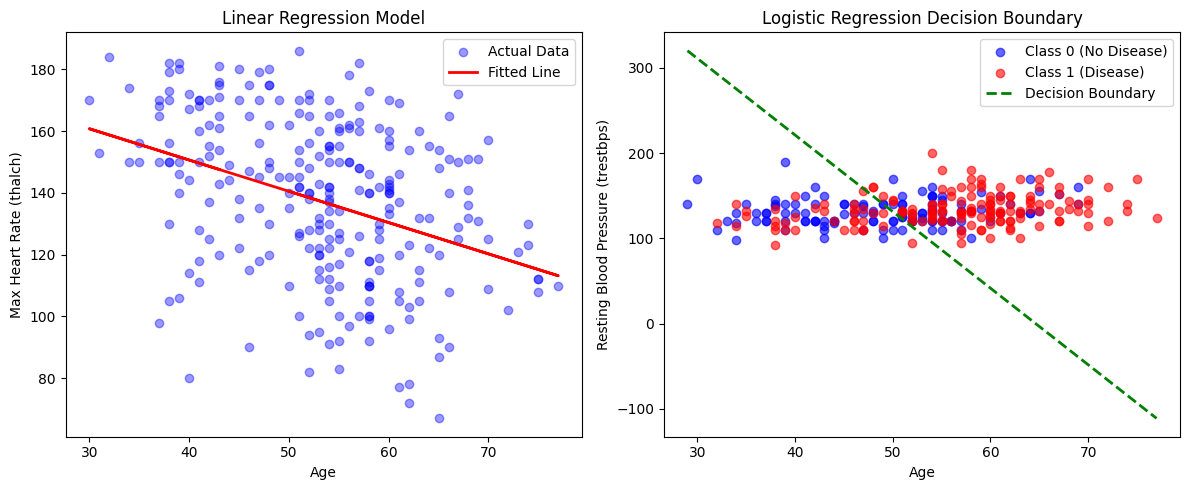

In [6]:
# Question 6: Plotting
plt.figure(figsize=(12, 5))

# 1. Regression Plot
plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, color='blue', alpha=0.4, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Fitted Line')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (thalch)')
plt.title('Linear Regression Model')
plt.legend()

# 2. Decision Boundary Plot
plt.subplot(1, 2, 2)
plt.scatter(X_te[y_te==0]['age'], X_te[y_te==0]['trestbps'], color='blue', label='Class 0 (No Disease)', alpha=0.6)
plt.scatter(X_te[y_te==1]['age'], X_te[y_te==1]['trestbps'], color='red', label='Class 1 (Disease)', alpha=0.6)

x1_vals = np.array([X_te['age'].min(), X_te['age'].max()])
x2_vals = -(w1 * x1_vals + b) / w2

plt.plot(x1_vals, x2_vals, color='green', linestyle='--', linewidth=2, label='Decision Boundary')
plt.xlabel('Age')
plt.ylabel('Resting Blood Pressure (trestbps)')
plt.title('Logistic Regression Decision Boundary')
plt.legend()

plt.tight_layout()
plt.show()

### Analytical Explanations & Theory Answers:

*Question 3 (Slope Interpretation):*
The slope value theta_1 (-1.0128) means that for every 1-year increase in a person's age, their predicted maximum heart rate (thalch) decreases by approximately 1.01 beats per minute.

*Question 5 (Precision & Recall for Class 1):*
- *Precision:* Represents the proportion of patients predicted as having heart disease who actually have it. High precision minimizes false positives.
- *Recall:* Represents the proportion of actual heart disease patients that were correctly identified by the model. High recall is vital in medical diagnosis to ensure no sick patient is missed.

*Question 7 (Theoretical Analysis):*
We use Binary Cross-Entropy (Log Loss) instead of Mean Squared Error (MSE) in Logistic Regression because combining MSE with the non-linear Sigmoid function results in a non-convex cost function with multiple local minima. This causes Gradient Descent to get stuck. Log Loss ensures a smooth convex cost function that guarantees reaching the global minimum.